# Week 12: Feature Engineering

This week we will cover the basics of Feature Engineering using pandas. Feature Engineering is an area of statistics focussed on transforming raw data into the most useful format for use in analysis including Machine Learning models. We will cover this in more detail in the model development and optimisation section of the course.

Feature Engineering can involve a number of things such as:
1. Feature Creation
2. Feature Transformation
   - Normalisation
   - Scaling
   - Encoding
3. Feature Extraction/Selection

Let's first import our required modules and reimport our data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('example_data.csv', names = ['Datetime', 'ActivePower', 'SpdMean', 'TheoreticalPower', 'Dir', 'SpdSD'], skiprows=1).dropna().reset_index(drop=True)
df['Datetime'] = pd.to_datetime(df.Datetime, format='mixed')
df = df[df.SpdMean>0].reset_index(drop=True)

In [3]:
def direction_sector(dirs, n=4):
    dir_sectors = []
    width = 360/n
    for dir in dirs:
        if dir<=45 or dir>315:
            dir_sectors.append('North')
        elif dir<=135:
            dir_sectors.append('East')
        elif dir<=225:
            dir_sectors.append('South')
        else:
            dir_sectors.append('West')
    return dir_sectors

df['Sector'] = direction_sector(df.Dir)

## 1 - Feature Creation

Feature creation involves making a new feature - these created features are sometimes referred to as *synthetic* features or variables. One method of creating new feautures is combining existing features. The most common example of this in wind energy is Turbulence Intensity - taking the ratio of Wind Speed standard deviation to Wind Speed mean.

In [4]:
df['TI'] = df['SpdSD']/df['SpdMean']
df = df.dropna().reset_index(drop=True)

Another common feature creation method is to extract or refine information from an existing variable, for example taking one element from the date such as month.

In [5]:
df['Month'] = [d.month for d in df.Datetime]

## 2 - Feature Transformation
### 2.1 - Normalisation and Scaling
Normalisation is a technique used to transform data to a standard scale. When we have multiple features of the model with very different magnitudes, for example standard deviation (between 0 and 1) and active power (up to 3500), the features with larger values may disproportionately influence the model. Normalising features reduces this effect. Additionally, having feature values within certain ranges can speed up optimisation and convergence of many machine learning algorithms, especially those which use gradient descent. The mechanisms behind these advantages will be explained in full in the machine learning part of the course. 
- Min-max normalisation: taking away the minimum of the data and dividing by the range, therefore scaling between 0 and 1
$$x_{i, normalised} = \frac{x_i-x_{min}}{x_{max}-x_{min}} $$
- Max-abs normalisation: divides by the absolute value of the maximum magnitude value
$$x_{i, normalised} = \frac{x_i}{|x_{magmax}|}$$
- Mean normalisation: takes away the mean, centering the feature around 0
$$x_{i, normalised} = x_i-\hat{x}$$
- Z-score normalisation: transforms data into a standard normal distribution by taking away the mean and dividing by the standard deviation
$$x_{i, normalised} = \frac{x_i-\hat{x}}{\sigma}$$
- Log normalisation: takes the logarithm of the data to reduce effect of extreme values (reduces skew)
$$x_{i, normalised} = \log(x_i)$$

In [6]:
# Calculate required statistics
min = df.SpdMean.min()
max = df.SpdMean.max()
absmagmax = df.SpdMean.abs().max()
mean = df.SpdMean.mean()
sd = df.SpdMean.std()

df['SpdMeanMinMaxNormalised'] = (df.SpdMean-min)/(max-min) 
df['SpdMeanMaxAbsNormalised'] = df.SpdMean/absmagmax
df['SpdMeanMeanNormalised'] = df.SpdMean-mean
df['SpdZScoreNormalised'] = (df.SpdMean-mean)/sd
df['SpdLogNormalised'] = [np.log(spd) for spd in df.SpdMean]

For now we only wish to retain one of these to avoid many speed predictive values, let's remove all columns except for the MinMax normalisation.

In [7]:
df = df.drop(columns = ['SpdMean', 'SpdMeanMaxAbsNormalised', 'SpdMeanMeanNormalised', 'SpdZScoreNormalised', 'SpdLogNormalised'])

Scaling is an umbrella term that can encompass normalisation, but can be more specifically used to refer to the adjustment to the spread of the data. For example, Z-score normalisation technically uses both normalisation (removal of the mean value) and scaling (dividing by standard deviation), even though we typically consider it to be a normalisation technique by name. We equivalently refer to standardisation (the exact same process) as a scaling technique.
- Standardisation: equivalent to Z-score normalisation, scaling features to have a mean of 0 and standard deviation of 1
$$x_{i, scaled} = \frac{x_i-\hat{x}}{\sigma}.$$

Other scaling techniques include
- Robust scaling: using the median and interquartile range to reduce outlier effect
$$x_{i, scaled} = \frac{x_i-x_{med}}{IQR}$$

Additionally, scaling can be used to describe other feature transformation techniques
- Feature scaling: umbrella term for any normalisation involving scaling
- Categorical scaling: umbrella term for encoding.

### 2.2 - Encoding

Encoding involves converting one format of data into another. The two main conversions we carry out are
- Converting continuous numerical data into binary based on a threshold value (e.g. below or above)
- Converting categorical data into numerical format (e.g. assigning a numerical value to each unique names string category)

#### 2.2.1 - Binary Encoding

We want to understand how often we would be exceeding the maximum power of our smaller wind turbine (2500 kW). Let's do a binary encoding of our ActivePower column to be True wherever ActivePower exceeds 2500 kW and False wherever ActivePower is less than 2500 kW. This encoding can be done with a single logic statement.

In [8]:
df['BinaryEncodedActivePower'] = df.ActivePower>2500

This new column has now *refined* the ActivePower variable into a simpler form which just tells us the key information.

Let's now look at the second type - there's lots of ways we can convert categorical data into numerical.

Common Encoding Techniques for Categorical Data
- One-hot encoding: creates a new binary column for each category in the original feature.
- Dummy encoding: works similarly to one-hot encoding but drops one category to avoid multicollinearity
- Original encoding: assigns a unique integer to each category reflecting order (e.g. low to 0, medium to 1, high to 2)
- Effect encoding: works similarly to original encoding but uses symmetry around 0 (e.g. -1, 0, 1) for better linear model handling
- Target/Mean encoding: replaces each category with the mean target/output value for that category
- Frequency/Count encoding: replaces each category with the frequency/count of occurrences of that category

### 2.2.2 - One-hot Encoding
One-hot encoding create a new column for each unique category. This column takes value one wherever the row falls into that category, and zero otherwise. We can use this by converting the boolean truth values from a logic statement into integer values.

In [9]:
df['isNorth'] = [int(val) for val in df.Sector=='North']

#### Exercise 2.2.2.1
Create columns 'isEast', 'isSouth' and 'isWest' using the same method, and drop the original Sector column.

In [10]:
df['isEast'] = [int(val) for val in df.Sector=='East']
df['isWest'] = [int(val) for val in df.Sector=='West']
df['isSouth'] = [int(val) for val in df.Sector=='South']

### 2.2.3 - Dummy Encoding

Dummy Encoding is very similar to One-hot Encoding, except instead of having one binary column for each category, we remove one. This is because this gives additional unnecessary information. If there are zeros in all other columns, then we know that the final category would have been 1. Conversely, if there is a 1 in another column we know the relevant category. Therefore we gain no additional information with this column. To convert the current df to have a Dummy Encoding, we would simply drop the West column.

#### Exercise 2.2.3.1
Drop the 'isWest' column

In [11]:
df = df.drop(columns=['isWest'])

#### 2.2.4 - Mapping Encodings

Mapping encodings (e.g. original, effect, target, frequency) work by mapping the unique categories to a numerical value. The easiest way to do this in Python is using a dictionary. The below code defines a dictionary for each encoding. Original and effect encodings may use a simple value map, whilst target and frequency encoding will require some pandas calculations.

In [12]:
original_encoding_dict = {'North':0, 'East':1, 'South':2, 'West':3}
effect_encoding_dict = {'West':-1, 'North':0, 'East':1, 'South':2}
target_encoding_dict = {dir:df[df.Sector==dir].ActivePower.mean() for dir in ['North', 'East', 'South', 'West']}
frequency_encoding_dict = {dir:len(df[df.Sector==dir]) for dir in ['North', 'East', 'South', 'West']}

Once we have a dictionary available we may map each value in our dataframe column using list comprehension.

In [13]:
df['SectorEncoded'] = [original_encoding_dict[sector] for sector in df.Sector]

#### Exercise 2.2.4.1 
Rewrite the code above to use target encoding instead.

In [14]:
df['SectorEncoded'] = [target_encoding_dict[sector] for sector in df.Sector]

#### Exercise 2.2.4.2
Write a dictionary mapping the month of the year to the season (Dec-Feb winter, Mar-May spring, Jun-Aug summer and Sept-Nov autumn). Create a new column called Season using this mapping.

In [15]:
season_dict = {1:'Winter', 2:'Winter', 3:'Spring', 4:'Spring', 5:'Spring', 6:'Summer', 7:'Summer', 8:'Summer', 9:'Autumn', 10:'Autumn', 11:'Autumn', 12:'Winter'}
df['Season'] = [season_dict[month] for month in df.Month]

## 3 - Feature Selection and Extraction

Feature selection and extraction methods are used to determine which features are most predictive within a model. This is particularly relevant when we have many input features, which would be computationally expensive to feed into a complex model, and thus we wish to only use the most relevant features.

### 3.1 - Removing Redundancy
When we create new or synthetic variables, we often create redundant variables. For example, where we have created turbulence intensity there is no longer the need for both wind speed mean and standard deviation as just two of the three variables contain all the information needed to calculate the third. Similarly with one-hot encoding we always create a redundant variable. Dummy encoding aims to avoid this by dropping one of the columns to reduce the redundancy. 

### 3.2 - Exploratory Data Analysis
Exploratory Data Analysis (EDA) generally refers to the preliminary investigation methods of exploring data through visualisations. We can use almost any of the plots mentioned in last week's tutorial, and at most basic may use scatter plots to view the continuous variables and bar charts to view the categorical variables.

**Continuous Variables**

<Axes: xlabel='SpdMeanMinMaxNormalised', ylabel='ActivePower'>

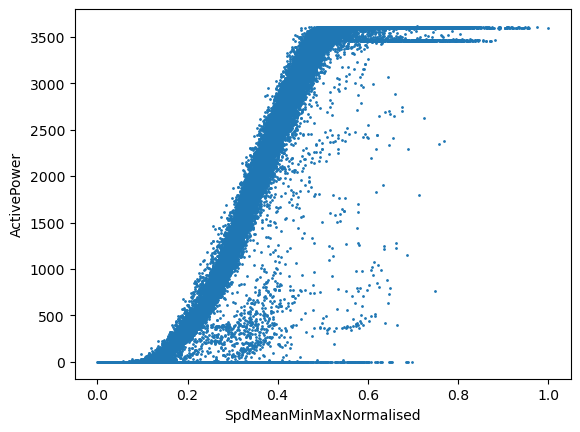

In [16]:
df.plot.scatter(x='SpdMeanMinMaxNormalised', y='ActivePower', s=1)

(0.0, 0.5)

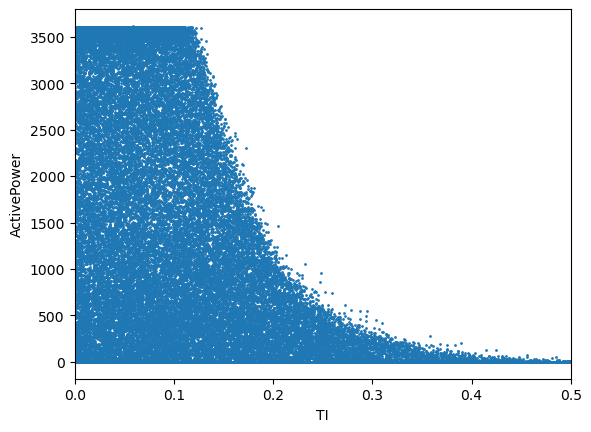

In [17]:
df.plot.scatter(x='TI', y='ActivePower', s=1)
plt.xlim(0,0.5)

<Axes: xlabel='SpdSD', ylabel='ActivePower'>

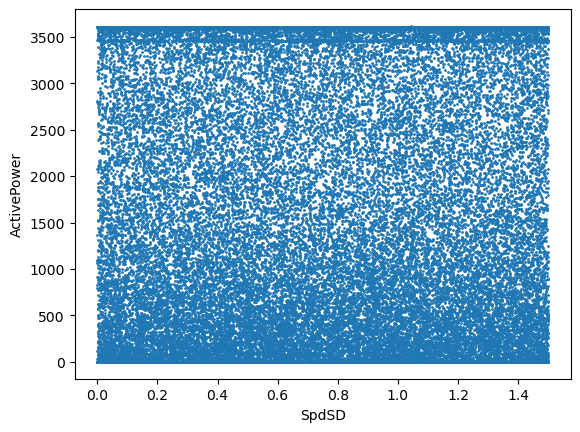

In [18]:
df.plot.scatter(x='SpdSD', y='ActivePower', s=1)

From these plots it seems that wind speed is highly related to active power, turbulence intensity has some relationship with active power, and standard deviation has no clear relationship with active power.

#### Exercise 3.2.1 
Plot wind direction against active power using either the same method as above, or the matplotlib package. Do these variables seem to have a relationship?

<Axes: xlabel='Dir', ylabel='ActivePower'>

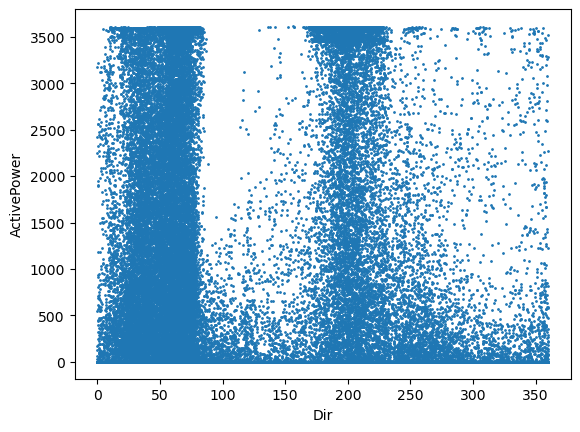

In [19]:
df.plot.scatter(x='Dir', y='ActivePower', s=1)

Yes, although they do not seem to have a linear or monotonic relationship, there are certainly directions that experience much higher active power values.

**Categorical Variables**

<Axes: >

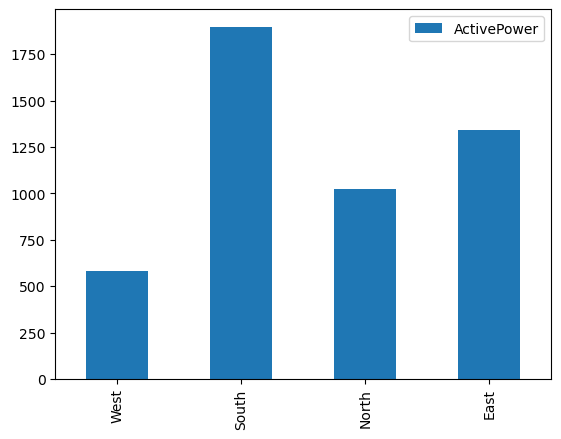

In [20]:
sector_barchart = pd.DataFrame({sector:df[df.Sector==sector].ActivePower.mean() for sector in df.Sector.unique()}, index=['ActivePower']).transpose()
sector_barchart.plot.bar()

#### Excercise 3.2.2
Alter the code above to create dataframe for the mean ActivePower values for each season

<Axes: >

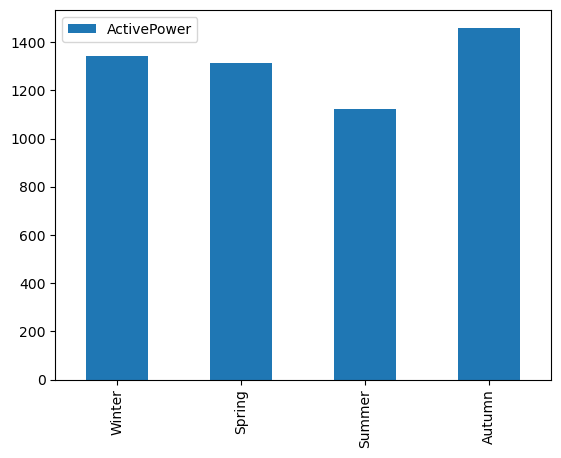

In [21]:
season_barchart = pd.DataFrame({season:df[df.Season==season].ActivePower.mean() for season in df.Season.unique()}, index=['ActivePower']).transpose()
season_barchart.plot.bar()

### 3.3 - Correlation
If we are creating a linear model, measuring the correlation of variables can give us an idea of the linear correlation between an input and output variable. A value close to 1 or -1 suggests a high measure of linear correlation, whilst values close to 0 show low linear predictivity. We can use the NumPy method corrcoeff(x,y) to measure the Pearson Correlation Coefficient. A positive value suggests a positive relationship (that as the input value increases the output value increases), whilst a negative value suggests a negative value (that as the input value increases, the output value decreases).

In [22]:
spd_corr = np.corrcoef(df.SpdMeanMinMaxNormalised, df.ActivePower)[0,1]
ti_corr = np.corrcoef(df.TI, df.ActivePower)[0,1]
dir_corr = np.corrcoef(df.Dir, df.ActivePower)[0,1]
sd_corr = np.corrcoef(df.SpdSD, df.ActivePower)[0,1]

print(f'Spd Corr: {spd_corr}')
print(f'SD Corr: {sd_corr}')
print(f'TI Corr: {ti_corr}')
print(f'Dir Corr: {dir_corr}')

Spd Corr: 0.9128001114828672
SD Corr: -0.0028522906117817684
TI Corr: -0.3948546201330673
Dir Corr: -0.06296039479636883


The above results suggests that:
- wind speed is highly linearly correlated with active power, and that as wind speed increases active power also increases. 
- speed standard deviation is unlikely to be linearly correlated with active power
- turbulence intensity is slightly linearly correlated with active power, and that as ti increases active power decreases
- direction is unlikely to be linearly correlated with active power

If we were determining which of the three variables to drop between wind speed mean, standard deviation and turbulence intensity, it is therefore likely we should drop standard deviation which seems the least predictive. However, correlation is not always linear. Another measure of correlation is the Spearman Correlation Coefficient, which instead measures the monotonic correlation, which may not be linear. This is not a measure include in the NumPy package, however we can import it from the Scipy Stats module.

In [23]:
from scipy.stats import spearmanr

In [24]:
spd_spearcorr = spearmanr(df.SpdMeanMinMaxNormalised, df.ActivePower).statistic
ti_spearcorr = spearmanr(df.TI, df.ActivePower).statistic
dir_spearcorr = spearmanr(df.Dir, df.ActivePower).statistic
sd_spearcorr = spearmanr(df.SpdSD, df.ActivePower).statistic

print(f'Spd Spearman Corr: {spd_spearcorr}')
print(f'SD Spearman Corr: {sd_spearcorr}')
print(f'TI Spearman Corr: {ti_spearcorr}')
print(f'Dir Spearman Corr: {dir_spearcorr}')

Spd Spearman Corr: 0.9328649055093368
SD Spearman Corr: -0.0038469352602125834
TI Spearman Corr: -0.5736750778145806
Dir Spearman Corr: -0.07806998086646878


Standard deviation also does not seem highly monotonically predictive, and did not seem visually predictive through exploratory data analysis (scatter plot). This therefore seems like a good candidate to drop.

In [25]:
df = df.drop(columns=['SpdSD'])

### 3.4 - Model-based Measures
Later in the course we will begin creating machine learning methods. Once we have done this we can use model-based measures such as sensitivity analysis in order to assess how predictive features are within the model (how much changing the input variable effects predicted output).